In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#################### Import libraries###################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time

In [3]:
breast_cancer_df = pd.read_csv('/content/drive/MyDrive/ProjectDatasets/breast-cancer.csv')
titanic_df = pd.read_csv('/content/drive/MyDrive/ProjectDatasets/Titanic-Dataset.csv')



#################### Prep Titanic dataset ###################
titanic_df = titanic_df.dropna()
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True)

#################### feature and target variables ###################
X_cancer = breast_cancer_df.drop(columns=['id', 'diagnosis'])
y_cancer = breast_cancer_df['diagnosis'].map({'M': 1, 'B': 0})

X_titanic = titanic_df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'])
y_titanic = titanic_df['Survived']

In [4]:
# Split datasets into train and test ###################
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42)
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

#################### Scale the data###################
scaler = StandardScaler()
X_train_cancer = scaler.fit_transform(X_train_cancer)
X_test_cancer = scaler.transform(X_test_cancer)
X_train_titanic = scaler.fit_transform(X_train_titanic)
X_test_titanic = scaler.transform(X_test_titanic)

In [5]:
#################### Define classifiers before tuning ###################
classifiers = {
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'Perceptron': Perceptron(),
    'Logistic Regression': LogisticRegression(max_iter=10000)
}

In [6]:
#################### function to plot validation curves ###################
def plot_validation_curve(clf, X, y, param_name, param_range, title):
    train_scores, test_scores = validation_curve(clf, X, y, param_name=param_name, param_range=param_range, cv=5, scoring='accuracy')
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure()
    plt.plot(param_range, train_scores_mean, label='Training score', color='blue')
    plt.plot(param_range, test_scores_mean, label='Cross-validation score', color='green')
    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

In [7]:
#################### Table to store results ###################
results = []

####################Function to train classifiers, get accuracy, training time and plot validation curves###################
def evaluate_classifier(clf_name, clf, X_train, X_test, y_train, y_test, param_name, param_range):
    print(f"Classifier: {clf_name} (Before Tuning)")

    ####################Validation curve before tuning###################
    plot_validation_curve(clf, X_train, y_train, param_name, param_range, f"{clf_name} Validation Curve (Before Tuning)")

    #################### Training and evaluation before tuning###################
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time
    y_pred = clf.predict(X_test)
    accuracy_before = accuracy_score(y_test, y_pred)

     ####################Hyperparameter tuning###################
    param_grid = {param_name: param_range}
    grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    #################### Best estimator after tuning ###################
    best_clf = grid_search.best_estimator_

    print(f"Best params for {clf_name}: {grid_search.best_params_}")

    #################### Validation curve after tuning ###################
    plot_validation_curve(best_clf, X_train, y_train, param_name, param_range, f"{clf_name} Validation Curve (After Tuning)")

    #################### Training and evaluation after tuning ###################
    start_time = time.time()
    best_clf.fit(X_train, y_train)
    training_time_after = time.time() - start_time
    y_pred_after = best_clf.predict(X_test)
    accuracy_after = accuracy_score(y_test, y_pred_after)

    #################### Store results ###################
    results.append({
        'Classifier': clf_name,
        'Accuracy Before Tuning': accuracy_before,
        'Accuracy After Tuning': accuracy_after,
        'Training Time Before': training_time,
        'Training Time After': training_time_after
    })

In [8]:
#################### Hyperparameters for validation curves ###################
param_ranges = {
    'Decision Tree': ('max_depth', np.arange(1, 10)),
    'KNN': ('n_neighbors', np.arange(1, 20)),
    'Perceptron': ('max_iter', np.arange(200, 1000, 200)),
    'Logistic Regression': ('C', np.logspace(-3, 3, 7))
}


Classifier: Decision Tree (Titanic) (Before Tuning)


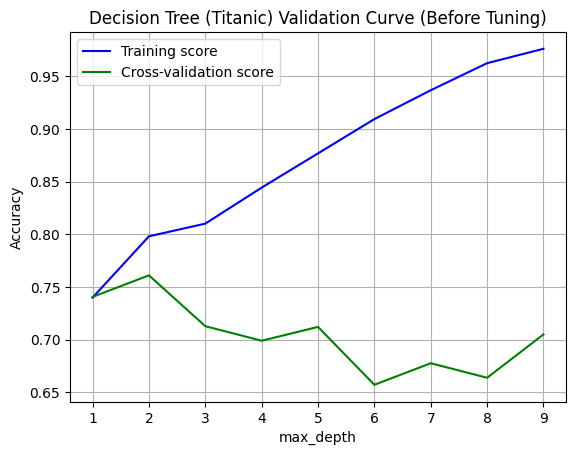

Best params for Decision Tree (Titanic): {'max_depth': 2}


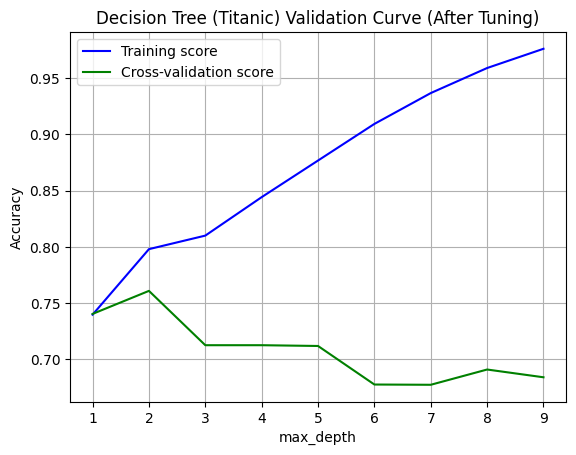

Classifier: Decision Tree (Breast Cancer) (Before Tuning)


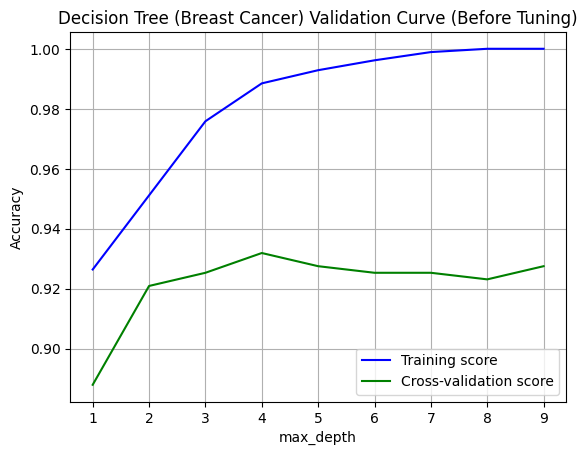

Best params for Decision Tree (Breast Cancer): {'max_depth': 5}


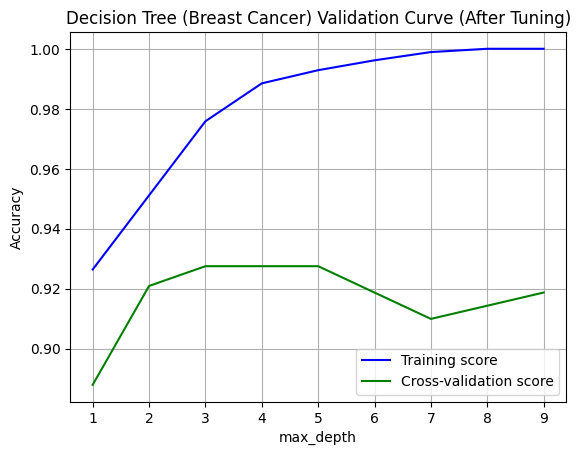

Classifier: KNN (Titanic) (Before Tuning)


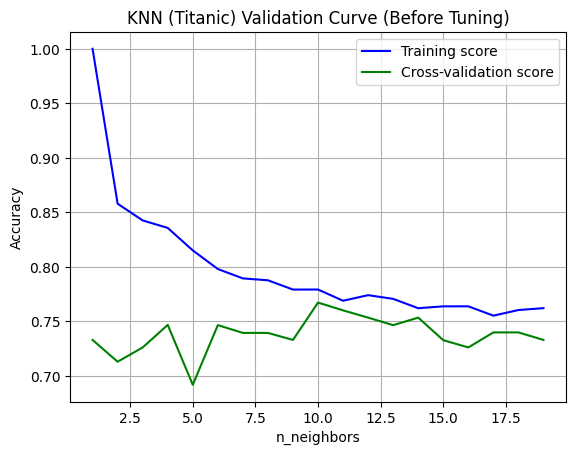

Best params for KNN (Titanic): {'n_neighbors': 10}


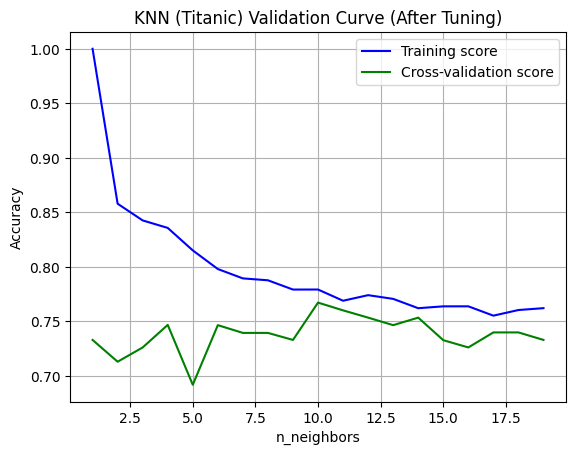

Classifier: KNN (Breast Cancer) (Before Tuning)


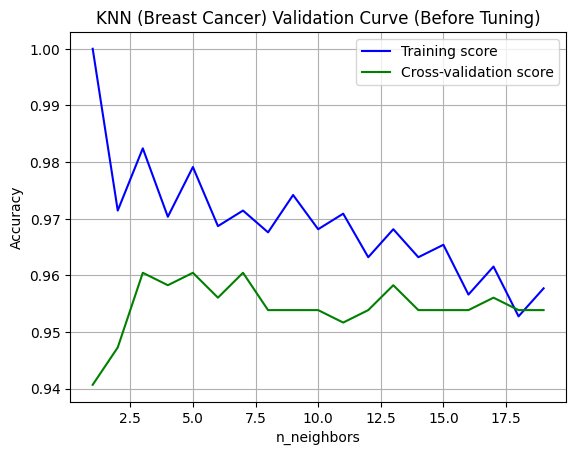

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best params for KNN (Breast Cancer): {'n_neighbors': 5}


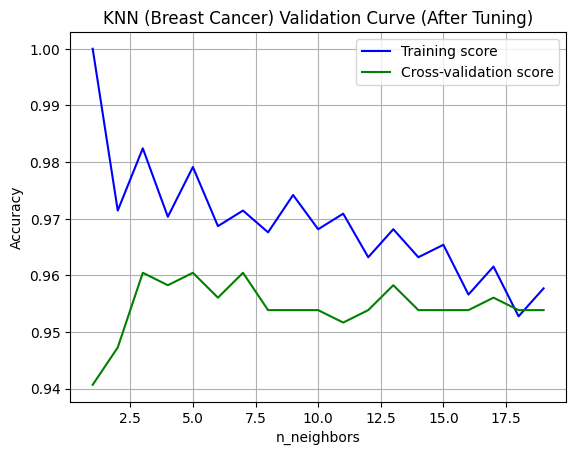

Classifier: Perceptron (Titanic) (Before Tuning)


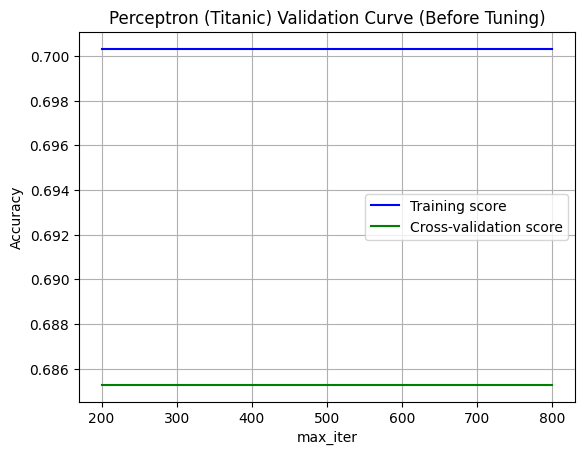

Best params for Perceptron (Titanic): {'max_iter': 200}


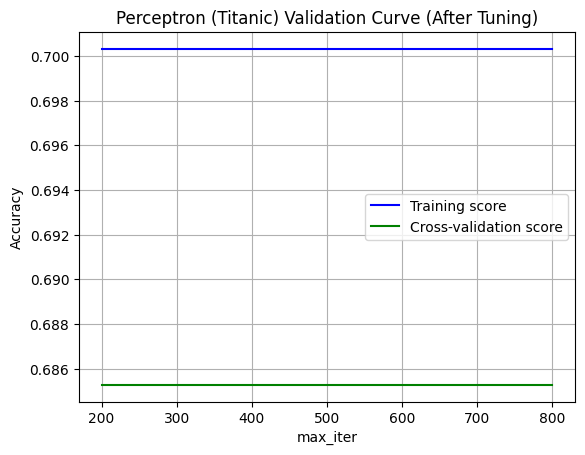

Classifier: Perceptron (Breast Cancer) (Before Tuning)


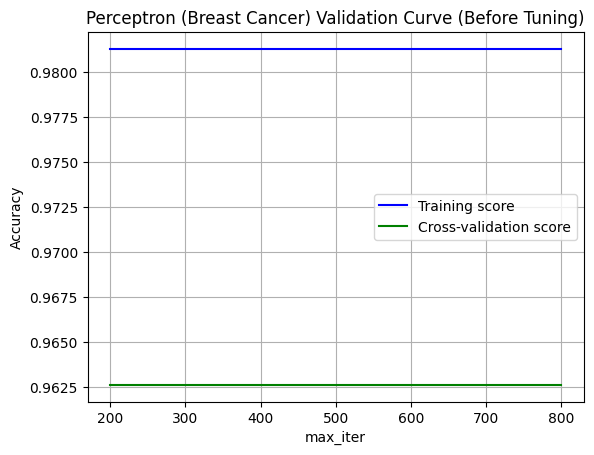

Best params for Perceptron (Breast Cancer): {'max_iter': 200}


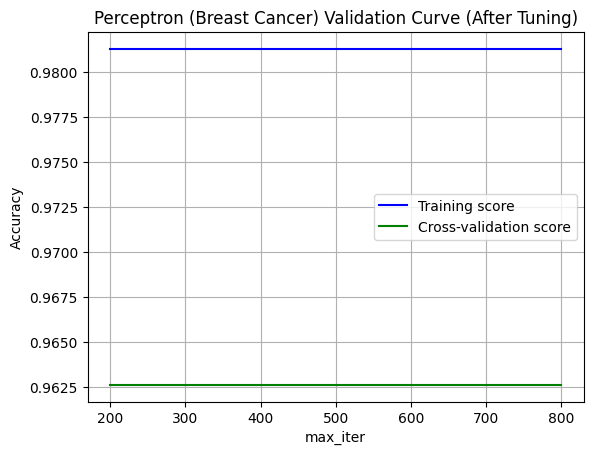

Classifier: Logistic Regression (Titanic) (Before Tuning)


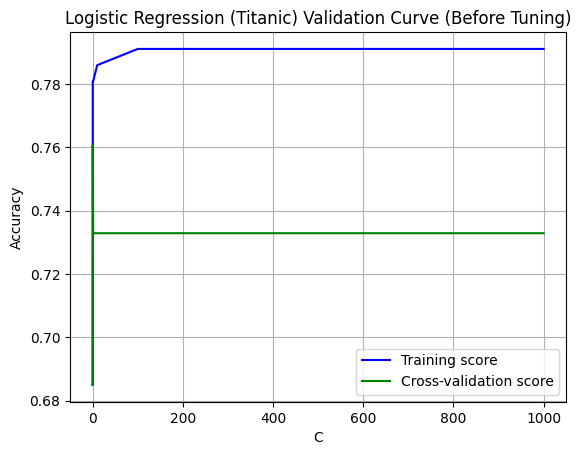

Best params for Logistic Regression (Titanic): {'C': 0.1}


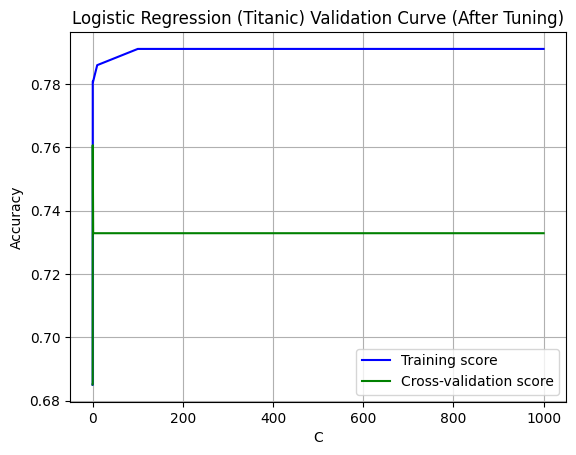

Classifier: Logistic Regression (Breast Cancer) (Before Tuning)


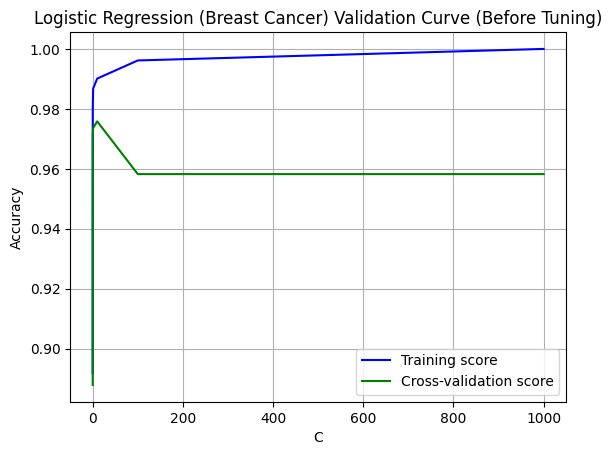

Best params for Logistic Regression (Breast Cancer): {'C': 10.0}


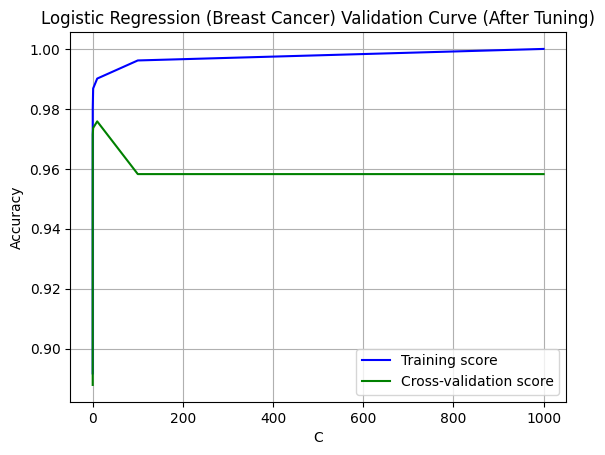

In [9]:
#################### Evaluate classifiers on both datasets ###################
for clf_name, clf in classifiers.items():
    param_name, param_range = param_ranges[clf_name]
    # For Titanic dataset
    evaluate_classifier(f"{clf_name} (Titanic)", clf, X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic, param_name, param_range)
    # For Breast Cancer dataset
    evaluate_classifier(f"{clf_name} (Breast Cancer)", clf, X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer, param_name, param_range)


In [10]:
#################### Convert results to a DataFrame ###################
results_df = pd.DataFrame(results)

In [11]:
#################### Print the results ###################
print(results_df)

                            Classifier  Accuracy Before Tuning  \
0              Decision Tree (Titanic)                0.702703   
1        Decision Tree (Breast Cancer)                0.947368   
2                        KNN (Titanic)                0.729730   
3                  KNN (Breast Cancer)                0.947368   
4                 Perceptron (Titanic)                0.540541   
5           Perceptron (Breast Cancer)                0.973684   
6        Logistic Regression (Titanic)                0.729730   
7  Logistic Regression (Breast Cancer)                0.973684   

   Accuracy After Tuning  Training Time Before  Training Time After  
0               0.810811              0.002637             0.008662  
1               0.938596              0.038393             0.019127  
2               0.756757              0.006422             0.002529  
3               0.947368              0.002472             0.002468  
4               0.540541              0.003300         

In [12]:
################### Save the results in csv files ###################

results_df.to_csv('/content/drive/MyDrive/ProjectDatasets/classifier_results.csv', index=False)